In [ ]:
# Credit Card Fraud Detection using XGBoost
# Objective: Build a machine learning model to identify fraudulent credit card transactions while handling severe class imbalance.

In [14]:
# Import required libraries .
import pandas as pd
import numpy as np

In [15]:
# Download dataset from kaggle .
import kagglehub
# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud


In [16]:
# Load the credit card transaction dataset into a pandas DataFrame.
df = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [17]:
# Examine the columns for basic statistical information.
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [18]:
# Analyze for missing values.
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [19]:
#Analyzing overall size of the dataset.
df.shape

(284807, 31)

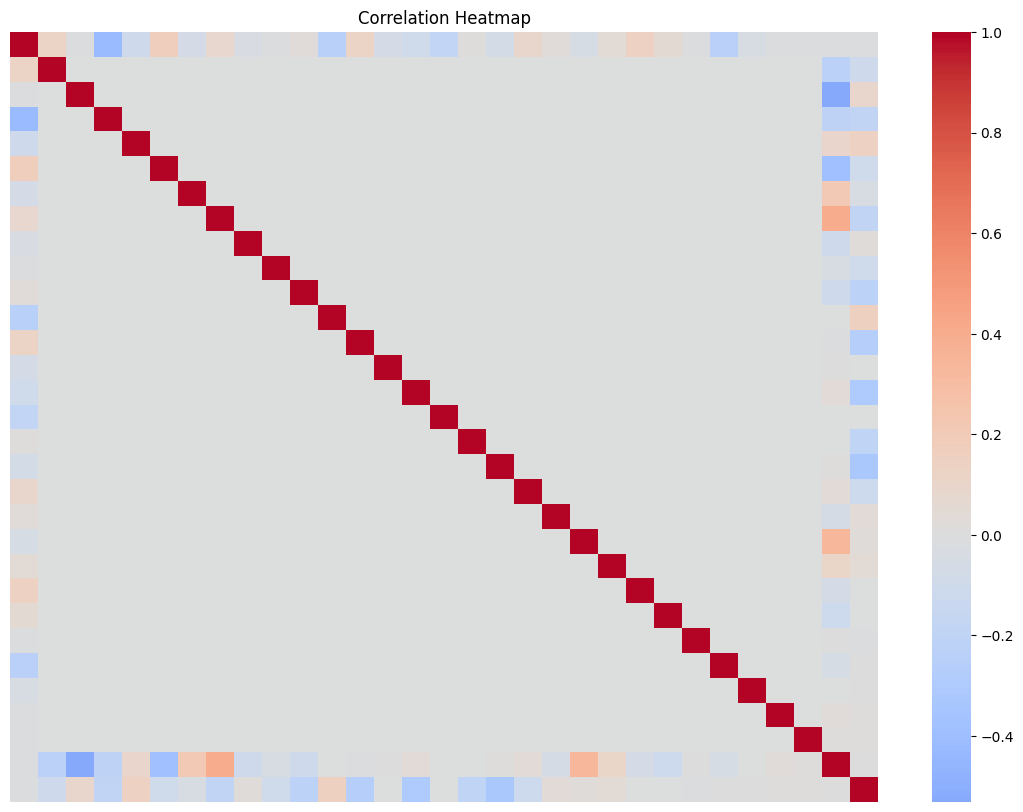

In [20]:
# Visualize correlations between numerical features to identify potential relationships and patterns.
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(14,10))
sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    center=0,
    xticklabels=False,
    yticklabels=False
)
plt.title("Correlation Heatmap")
plt.show()


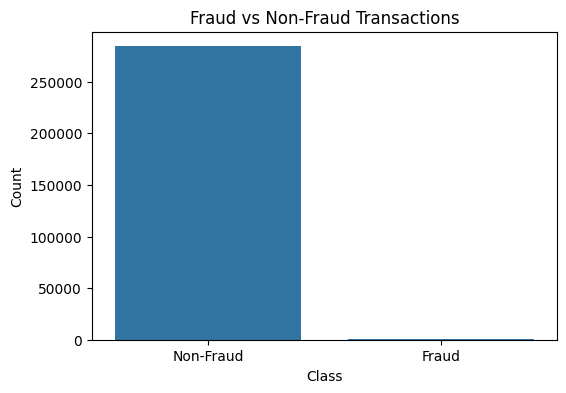

In [21]:
# Analyze the distribution of fraudulent and non-fraudulent transactions to understand dataset imbalance.
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.xticks([0,1], ["Non-Fraud", "Fraud"])
plt.ylabel("Count")
plt.show()


In [22]:
# Calculate the percentage distribution of each class to check class imbalance.
counts = df['Class'].value_counts(normalize=True) * 100
print(counts)


Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


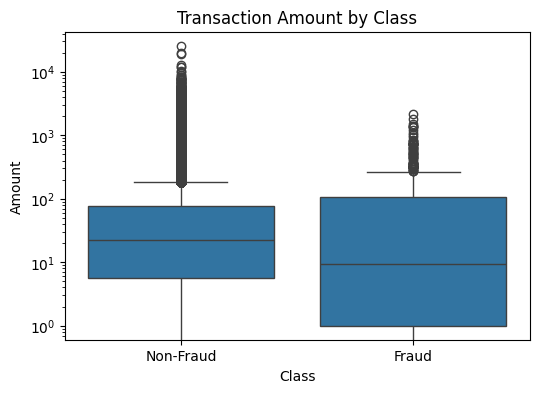

In [23]:
# Compare transaction amount distributions between fraudulent and non-fraudulent transactions to identify differences, outliers, and spending patterns.

plt.figure(figsize=(6,4))
sns.boxplot(x='Class', y='Amount', data=df)
plt.xticks([0,1], ["Non-Fraud", "Fraud"])
plt.title("Transaction Amount by Class")
plt.yscale('log')   
plt.show()


In [24]:
# Seperate input and output variables (features and target).
X = df.iloc[: , : 30]
y = df['Class']


In [25]:
# Split data into training and testing sets to evaluate model performance on unseen transactions using 20% of the data to test the model.
from sklearn.model_selection import train_test_split
X_train , X_test , Y_train , Y_test = train_test_split(X, y , test_size = 0.2 , random_state = 1)


In [26]:
# Standardize numerical features to improve model training and ensure consistent feature ranges.
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
# Display the number of samples in each class within the training dataset
from collections import Counter
counts = Counter(Y_train)
print(counts)

Counter({0: 227451, 1: 394})


In [28]:
# Apply SMOTE(Synthetic Minority Oversampling Technique) to generate synthetic fraud samples and reduce class imbalance in the training data.
from imblearn.over_sampling import SMOTE
sm = SMOTE(sampling_strategy = 0.7 , random_state = 1 , k_neighbors = 6)
X_train , Y_train = sm.fit_resample(X_train , Y_train)

In [31]:
# Define parameter distributions for RandomizedSearchCV to identify the optimal model configuration.
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from scipy.stats import randint , uniform
b_model = XGBClassifier(random_state = 1)
parm_dist = {"n_estimators" : randint(100 , 2000) , 
             "max_depth" : randint(5,20) , 
             "learning_rate" : uniform(1e-5 , 0.1),
             "subsample" : uniform(0.1 , 0.9) , 
             "colsample_bytree" : uniform(0.1 , 0.9),
            }
rs = RandomizedSearchCV(b_model , param_distributions = parm_dist , scoring='roc_auc' , n_iter = 50 , cv = 3 , n_jobs = -1)



In [32]:
# Train RandomizedSearchCV to evaluate multiple random hyperparameter combinations using cross-validation and identify the best-performing model configuration.
rs.fit(X_train , Y_train)

RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                        'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7d6806a26810>,
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d681964a420>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d681964a180>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7d68060eea80>},
                   scoring='roc_auc')

In [33]:
# Retrieve the best-performing model identified during RandomizedSearchCV based on cross-validation results.
model = rs.best_estimator_

In [34]:
# Convert predicted fraud probabilities into binary class labels using a custom threshold to improve fraud detection sensitivity.
Y_prob = model.predict_proba(X_test)[:,1]
Y_pred = (Y_prob > 0.3).astype(int)

In [35]:
# Count the number of incorrectly classified transactions(optional)
c = 0
for i in range(len(Y_pred)):
    if Y_pred[i] != Y_test.iloc[i]:
        c += 1
print("Misclassified:", c)


Misclassified: 35


In [36]:
# Evaluate model performance using multiple classification metrics to assess fraud detection capability on the test dataset.

from sklearn.metrics import *
print(confusion_matrix(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred))
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("Precision:", precision_score(Y_test, Y_pred))
print("Recall:", recall_score(Y_test, Y_pred))
print("F1:", f1_score(Y_test, Y_pred))
print("Balanced Acc:", balanced_accuracy_score(Y_test, Y_pred))
print("MCC:", matthews_corrcoef(Y_test, Y_pred))


[[56843    21]
 [   14    84]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.80      0.86      0.83        98

    accuracy                           1.00     56962
   macro avg       0.90      0.93      0.91     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy: 0.999385555282469
Precision: 0.8
Recall: 0.8571428571428571
F1: 0.8275862068965517
Balanced Acc: 0.9283867774740735
MCC: 0.82777284268438


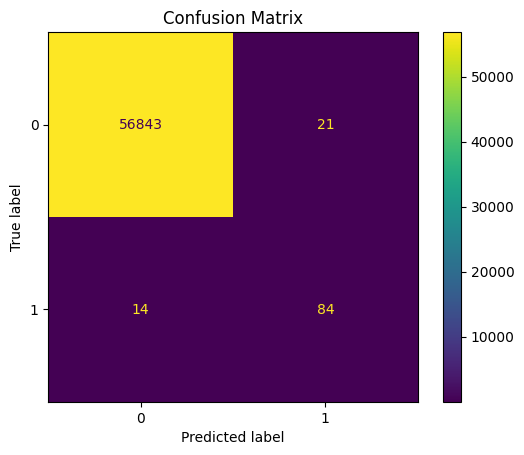

In [40]:
# Visualize model predictions using a confusion matrix to analyze correctly classified transactions and errors.
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(Y_test, Y_pred)
plt.title("Confusion Matrix")
plt.show()

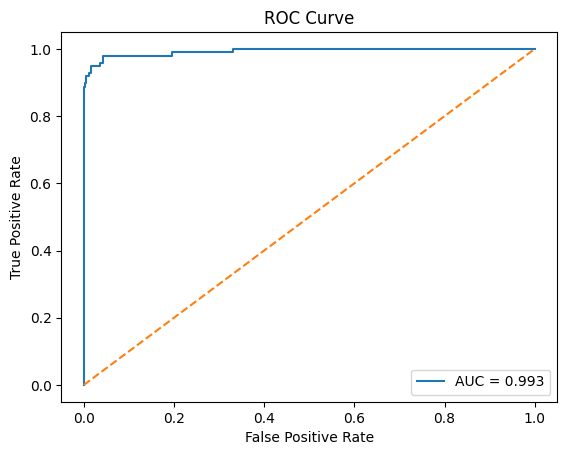

In [39]:
# Plot the ROC curve and compute the Area Under the Curve (AUC) to evaluate the model's ability to distinguish between fraudulent and legitimate transactions across all thresholds.
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(Y_test, Y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [37]:
# Save the trained model for future use, deployment,and inference without retraining.
import joblib
joblib.dump(model, 'best_model.pkl')


['/kaggle/working/best_model.pkl']